# Fundamental Ratios

## Overview

This notebook demonstrates the public functions in `fundamental_ratios`.

- Problem: fundamental modeling requires a consistent period-by-feature table containing the available efficiency, liquidity, profitability, solvency, and valuation ratios.
- Approach: construct efficiency, liquidity, profitability, solvency, and valuation ratios from observed data.

## Observed Data

This cell defines a single-symbol request for observed quarterly fundamental ratios.

- `symbol` identifies the equity whose ratios are calculated.
- `start` contains the inclusive UTC interval start.
- `end` contains the inclusive UTC interval end.
- `trailing` is `None`, so each ratio represents its individual reporting quarter.
- `output_path` is `None`, so the dataset is saved at `data/research_data/fundamental/features/`.

In [1]:
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_preprocessing.fundamental_ratios import save_fundamental_ratios

symbol = "AAPL"
start = datetime(2025, 1, 1, tzinfo=timezone.utc)
end = datetime(2025, 12, 31, tzinfo=timezone.utc)
trailing = None
output_path = None

## Fundamental Ratio Feature Table

This cell fetches and saves the transposed fundamental-ratio table, then reports its model-ready feature fields.

- `period` identifies the quarterly reporting period represented by each row.
- `symbol` identifies the equity shared by all ratio values in the row.

In [2]:
saved_path = save_fundamental_ratios(
    symbol=symbol,
    start=start,
    end=end,
    trailing=trailing,
    output_path=output_path,
)

fundamental_features = pd.read_parquet(saved_path)
display(fundamental_features.head())

2026-08-04 14:25:51 - financetoolkit - INFO - Obtaining financial statements
2026-08-04 14:25:51 - financetoolkit - INFO - Obtaining balance data for 1 ticker(s)
2026-08-04 14:25:52 - financetoolkit - INFO - Obtaining income data for 1 ticker(s)
2026-08-04 14:25:53 - financetoolkit - INFO - Obtaining cashflow data for 1 ticker(s)
2026-08-04 14:25:54 - financetoolkit - INFO - Obtaining treasury data for 1 ticker(s)
2026-08-04 14:25:55 - financetoolkit - INFO - Obtaining historical data for 2 ticker(s)
2026-08-04 14:25:57 - financetoolkit - INFO - Obtaining treasury data for 1 ticker(s)
2026-08-04 14:25:58.479 | INFO     | src.data_preprocessing.fundamental_ratios:save_fundamental_ratios:104 - Saved 3 fundamental ratio periods to /Users/kwonjunhyuk9/Documents/financial-machine-learning/data/research_data/fundamental/features/aapl_2025-01-01_2025-12-31.parquet.


,period,symbol,Days of Inventory Outstanding,Days of Sales Outstanding,Operating Cycle,Days of Accounts Payable Outstanding,Cash Conversion Cycle,Cash Conversion Efficiency,Receivables Turnover,Inventory Turnover Ratio,...,EV-to-Sales,EV-to-EBIT,EV-to-EBITDA,EV-to-Operating-Cash-Flow,Tangible Asset Value,Net Current Asset Value,EV-to-Free-Cash-Flow,Buyback Yield,Shareholder Yield,SBC-Adjusted Free Cash Flow
0,2025Q2,AAPL,NaN,NaN,NaN,NaN,NaN,0.2963,NaN,NaN,...,33.3101,111.7458,100.9393,112.4034,65830000000.0,-18629000000.0,128.3486,0.0069,0.0069,21237000000.0
1,2025Q3,AAPL,9.8145,29.9818,39.7963,101.352,-61.5557,0.2901,0.3286,9.2974,...,38.033,118.7992,109.6104,131.0915,73733000000.0,-17674000000.0,147.1377,0.0053,0.0063,23303000000.0
2,2025Q4,AAPL,7.0974,25.2944,32.3918,85.9832,-53.5914,0.3751,0.2772,12.8569,...,28.3225,79.8309,75.3068,75.5037,88190000000.0,-4263000000.0,78.9792,0.0061,0.0071,47958000000.0


## Efficiency Ratios

Efficiency ratios describe how effectively a company converts its operating resources into revenue and cash. This cell selects three representative efficiency features from the saved table.

- `Asset Turnover Ratio` measures revenue generated per unit of average assets.
- `Inventory Turnover Ratio` measures how often average inventory is sold during the period.
- `Cash Conversion Cycle` estimates the number of days between paying suppliers and collecting cash from customers.

In [3]:
efficiency_columns = [
    "Asset Turnover Ratio",
    "Inventory Turnover Ratio",
    "Cash Conversion Cycle",
]
efficiency_features = fundamental_features.set_index("period")[efficiency_columns]
display(efficiency_features)

,Asset Turnover Ratio,Inventory Turnover Ratio,Cash Conversion Cycle
period,,,
2025Q2,NaN,NaN,NaN
2025Q3,0.2967,9.2974,-61.5557
2025Q4,0.3893,12.8569,-53.5914


## Efficiency Ratio Trends

This cell visualizes the quarterly efficiency ratios in separate panels.

- The horizontal axis identifies the reporting period.
- The vertical axes report asset turnover as a multiple, inventory turnover as turns, and the cash conversion cycle as days.

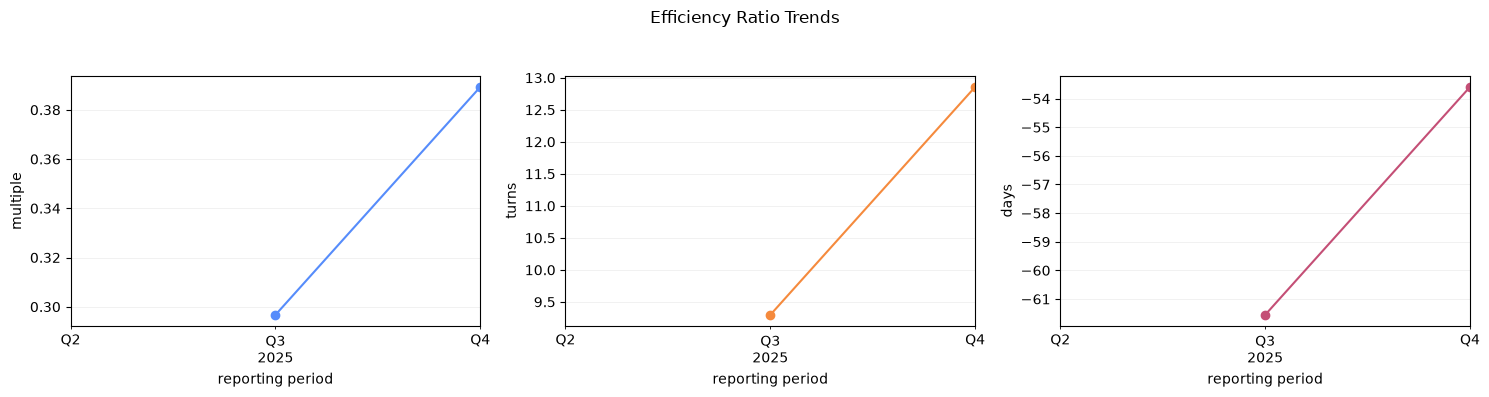

In [4]:
efficiency_axes = efficiency_features.plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    marker="o",
    legend=False,
)
for axis, y_label in zip(
    efficiency_axes.ravel(),
    ("multiple", "turns", "days"),
):
    axis.set_xlabel("reporting period")
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.25)

plt.suptitle("Efficiency Ratio Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Liquidity Ratios

Liquidity ratios describe a company's capacity to meet near-term obligations with current assets and operating cash flow. This cell selects three representative liquidity features from the saved table.

- `Current Ratio` compares current assets with current liabilities.
- `Quick Ratio` excludes less-liquid current assets such as inventory from the coverage measure.
- `Operating Cash Flow Ratio` compares operating cash flow with current liabilities.

In [5]:
liquidity_columns = [
    "Current Ratio",
    "Quick Ratio",
    "Operating Cash Flow Ratio",
]
liquidity_features = fundamental_features.set_index("period")[liquidity_columns]
display(liquidity_features)

,Current Ratio,Quick Ratio,Operating Cash Flow Ratio
period,,,
2025Q2,0.868,0.5876,0.1975
2025Q3,0.8933,0.5704,0.1795
2025Q4,0.9737,0.6579,0.3321


## Liquidity Ratio Trends

This cell visualizes the quarterly liquidity ratios in separate panels.

- The horizontal axis identifies the reporting period.
- Each vertical axis reports its unitless liquidity ratio on an independent scale.

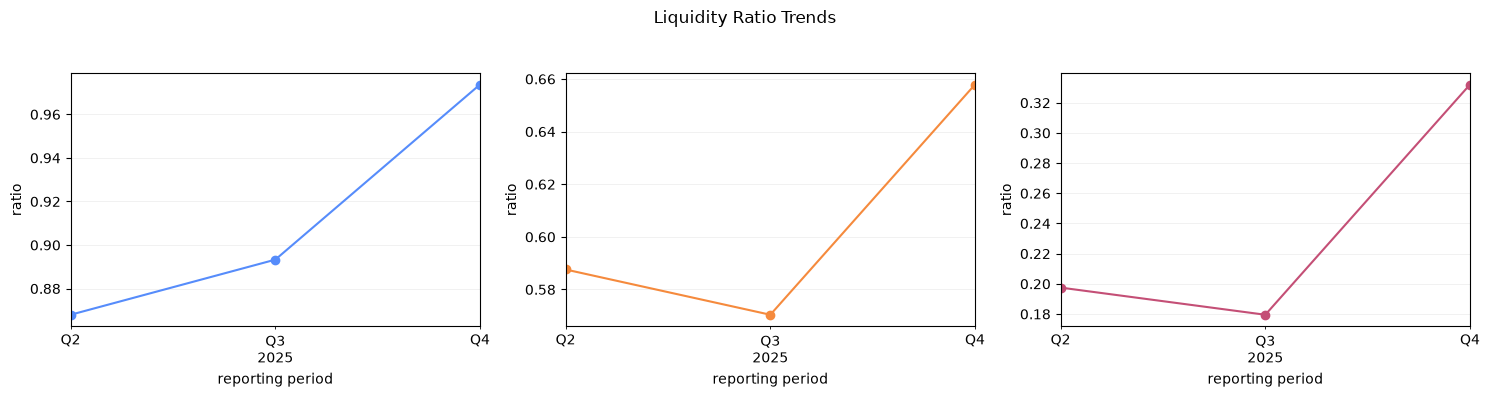

In [6]:
liquidity_axes = liquidity_features.plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    marker="o",
    legend=False,
)
for axis in liquidity_axes.ravel():
    axis.set_xlabel("reporting period")
    axis.set_ylabel("ratio")
    axis.grid(alpha=0.25)

plt.suptitle("Liquidity Ratio Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Profitability Ratios

Profitability ratios describe how much profit a company produces from revenue and shareholder capital. This cell selects three representative profitability features from the saved table.

- `Gross Margin` reports gross profit as a share of revenue.
- `Operating Margin` reports operating income as a share of revenue.
- `Return on Equity` reports net income relative to average shareholders' equity.

In [7]:
profitability_columns = [
    "Gross Margin",
    "Operating Margin",
    "Return on Equity",
]
profitability_features = fundamental_features.set_index("period")[
    profitability_columns
]
display(profitability_features)

,Gross Margin,Operating Margin,Return on Equity
period,,,
2025Q2,0.4649,0.2999,NaN
2025Q3,0.4718,0.3165,0.3936
2025Q4,0.4816,0.3537,0.52


## Profitability Ratio Trends

This cell visualizes the quarterly profitability ratios in separate panels.

- The horizontal axis identifies the reporting period.
- Each vertical axis reports profitability as a decimal ratio, where `0.25` represents 25 percent.

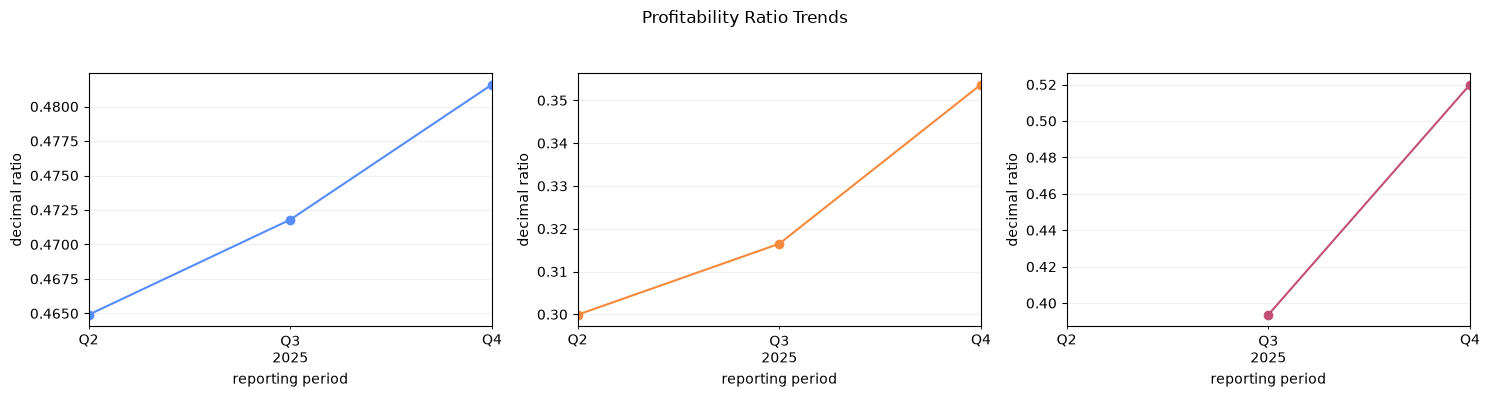

In [8]:
profitability_axes = profitability_features.plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    marker="o",
    legend=False,
)
for axis in profitability_axes.ravel():
    axis.set_xlabel("reporting period")
    axis.set_ylabel("decimal ratio")
    axis.grid(alpha=0.25)

plt.suptitle("Profitability Ratio Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Solvency Ratios

Solvency ratios describe a company's long-term debt burden and its capacity to support that debt with assets, equity, or earnings. This cell selects three representative solvency features from the saved table.

- `Debt-to-Assets Ratio` reports debt relative to total assets.
- `Debt-to-Equity Ratio` reports debt relative to shareholders' equity.
- `Net-Debt to EBITDA Ratio` compares net debt with earnings before interest, taxes, depreciation, and amortization.

In [9]:
solvency_columns = [
    "Debt-to-Assets Ratio",
    "Debt-to-Equity Ratio",
    "Net-Debt to EBITDA Ratio",
]
solvency_features = fundamental_features.set_index("period")[solvency_columns]
display(solvency_features)

,Debt-to-Assets Ratio,Debt-to-Equity Ratio,Net-Debt to EBITDA Ratio
period,,,
2025Q2,0.3068,1.5449,2.1084
2025Q3,0.3128,1.5241,2.1501
2025Q4,0.2386,1.0263,0.8359


## Solvency Ratio Trends

This cell visualizes the quarterly solvency ratios in separate panels.

- The horizontal axis identifies the reporting period.
- Each vertical axis reports its leverage ratio on an independent scale.

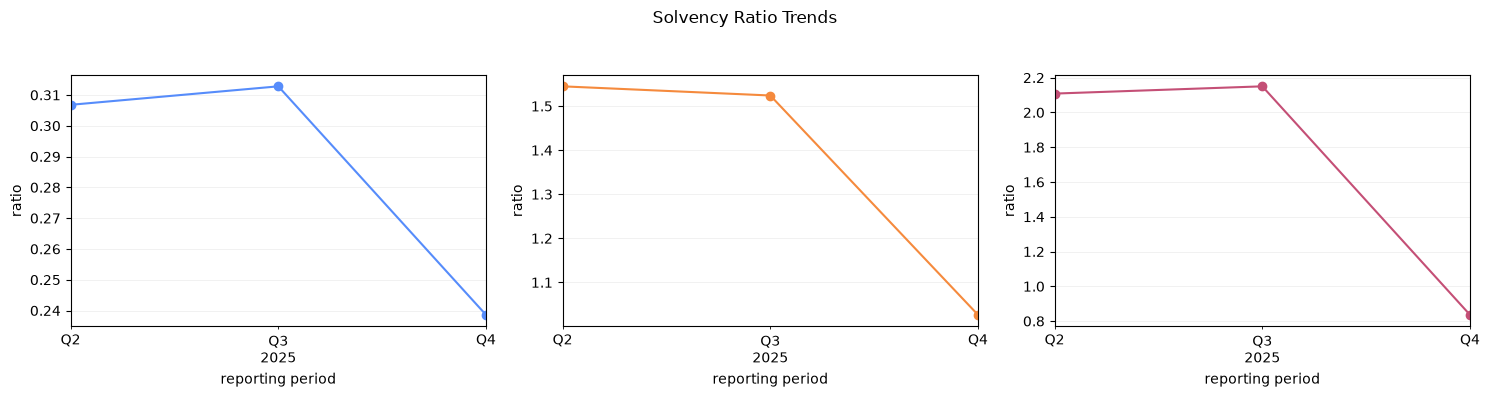

In [10]:
solvency_axes = solvency_features.plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    marker="o",
    legend=False,
)
for axis in solvency_axes.ravel():
    axis.set_xlabel("reporting period")
    axis.set_ylabel("ratio")
    axis.grid(alpha=0.25)

plt.suptitle("Solvency Ratio Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Valuation Ratios

Valuation ratios compare the market value of a company with accounting or operating fundamentals. This cell selects three representative valuation features from the saved table.

- `Price-to-Book` compares equity market value with book equity.
- `EV-to-Sales` compares enterprise value with revenue.
- `EV-to-EBITDA` compares enterprise value with earnings before interest, taxes, depreciation, and amortization.

In [11]:
valuation_columns = [
    "Price-to-Book",
    "EV-to-Sales",
    "EV-to-EBITDA",
]
valuation_features = fundamental_features.set_index("period")[valuation_columns]
display(valuation_features)

,Price-to-Book,EV-to-Sales,EV-to-EBITDA
period,,,
2025Q2,46.5883,33.3101,100.9393
2025Q3,51.8173,38.033,109.6104
2025Q4,45.6555,28.3225,75.3068


## Valuation Ratio Trends

This cell visualizes the quarterly valuation multiples in separate panels.

- The horizontal axis identifies the reporting period.
- Each vertical axis reports its valuation multiple on an independent scale.

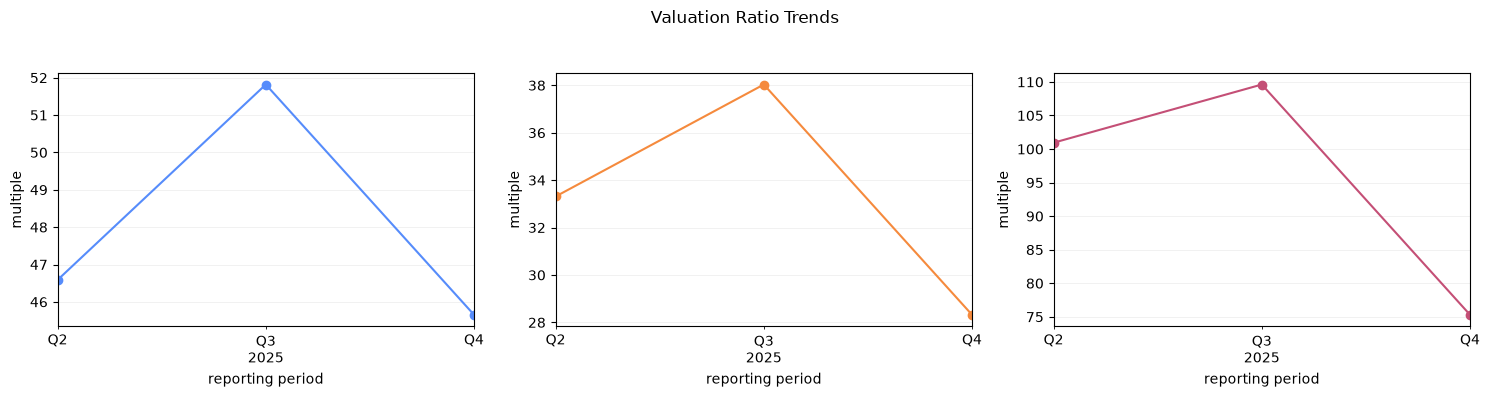

In [12]:
valuation_axes = valuation_features.plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    marker="o",
    legend=False,
)
for axis in valuation_axes.ravel():
    axis.set_xlabel("reporting period")
    axis.set_ylabel("multiple")
    axis.grid(alpha=0.25)

plt.suptitle("Valuation Ratio Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()